# CREATOR COMPASS EDA: Engagement Prediction

## Part 1: Data Quality Assessment

**Goal:** Ensure data is clean, reliable, and ready for analysis

### Step 1.1: Load and Inspect Data

Load the combined dataset and verify basic properties

In [44]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11


In [45]:
# Load the combined training dataset
df = pd.read_csv('../../data/processed/combined_training.csv', low_memory=False)

# Basic dataset information

print("DATASET OVERVIEW")

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print("\n" + "="*70)

DATASET OVERVIEW
Dataset shape: 82,476 rows × 31 columns
Memory usage: 69.8 MB



In [46]:
# Display first 5 rows
df.head()

,content_id,platform,category,caption,caption_length,hashtag_count,hashtags,duration_sec,views,likes,...,posting_month,posting_year,sentiment,has_emoji,emoji_count,has_call_to_action,has_question,word_count,trend_label,data_source
0,7606525547610524942,tiktok,general,#rich #richlifestyle #penthouse,32,3,"['rich', 'richlifestyle', 'penthouse']",28.0,377800,61200,...,2,2026,neutral,False,0.0,False,0.0,3.0,NaN,scraped_apify
1,7597408819181931797,tiktok,general,Better late than never 👌🏽✨☁️ #lilbro #lifestyl...,73,5,"['lilbro', 'lifestyle', 'fyp', 'gamer', 'dayin...",170.0,1700000,158500,...,1,2026,neutral,True,1.0,False,0.0,10.0,NaN,scraped_apify
2,7366355450830261509,tiktok,general,If you need some content ideas and tips to gro...,234,8,"['contentcreatortips', 'greenscreen', 'content...",173.0,1400000,107600,...,5,2024,neutral,True,2.0,True,0.0,28.0,NaN,scraped_apify
3,7604229327680556321,tiktok,general,#money #rich #lifestyle #motivation #luxury,44,5,"['money', 'rich', 'lifestyle', 'motivation', '...",21.0,387400,68300,...,2,2026,neutral,False,0.0,False,0.0,5.0,NaN,scraped_apify
4,7600840983827189022,tiktok,general,#contentideas well more of a reframing how we ...,115,4,"['contentideas', 'lifestylecontent', 'stopover...",569.0,344200,52300,...,1,2026,neutral,False,0.0,False,0.0,13.0,NaN,scraped_apify


In [47]:
# Check data types
print("Data Types:")

print(df.dtypes)


Data Types:
content_id                 object
platform                   object
category                   object
caption                    object
caption_length              int64
hashtag_count               int64
hashtags                   object
duration_sec              float64
views                       int64
likes                       int64
comments                    int64
shares                      int64
saves                       int64
engagement_rate           float64
engagement_score          float64
engagement_rating          object
creator_username           object
creator_follower_count    float64
creator_verified          float64
posting_hour                int64
posting_day                object
posting_month               int64
posting_year                int64
sentiment                  object
has_emoji                  object
emoji_count               float64
has_call_to_action         object
has_question              float64
word_count                float64
tr

In [48]:
# Basic statistical summary
print("Statistical Summary of Numerical Features:")
df.describe().T

Statistical Summary of Numerical Features:


,count,mean,std,min,25%,50%,75%,max
caption_length,82476.0,65.296244,7.459886e+01,0.0,22.000000,28.0000,116.0000,3.377000e+03
hashtag_count,82476.0,3.813546,3.972694e+00,0.0,1.000000,1.0000,7.0000,7.700000e+01
duration_sec,52477.0,36.008175,3.560322e+01,0.0,22.000000,31.0000,43.0000,3.600000e+03
views,82476.0,288122.561048,3.273101e+06,12.0,6495.750000,27883.0000,85227.2500,4.392000e+08
likes,82476.0,20187.797638,2.239416e+05,0.0,286.000000,1399.5000,4681.2500,1.650000e+07
comments,82476.0,481.238457,1.980888e+03,0.0,9.000000,131.0000,463.0000,2.484000e+05
shares,82476.0,2076.219700,3.843227e+04,0.0,15.000000,126.0000,439.0000,5.900000e+06
saves,82476.0,2479.080811,3.030712e+04,0.0,38.000000,135.0000,457.0000,3.832277e+06
engagement_rate,82476.0,0.638536,3.001328e+00,0.0,0.040500,0.0606,0.0867,8.151408e+01
engagement_score,82476.0,4.626778,1.912083e+00,0.0,3.044575,4.8515,6.1701,1.584067e+01


### Step 1.2: Missing Data Analysis

Identify missing values and decide on handling strategy

In [49]:
# Calculate missing data summary
missing_summary = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing_Percent', ascending=False)

# Filter to show only columns with missing values
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]


print("Missing Dat Summary ")

print(missing_summary)
print(f"\nTotal columns with missing data: {len(missing_summary)}")


Missing Dat Summary 
                        Missing_Count  Missing_Percent
creator_verified                78078            94.67
sentiment                       78078            94.67
emoji_count                     78078            94.67
word_count                      78078            94.67
has_question                    78078            94.67
creator_follower_count          48079            58.29
has_call_to_action              48079            58.29
trend_label                     34397            41.71
caption                         30025            36.40
duration_sec                    29999            36.37
hashtags                        29999            36.37
has_emoji                       29999            36.37

Total columns with missing data: 12


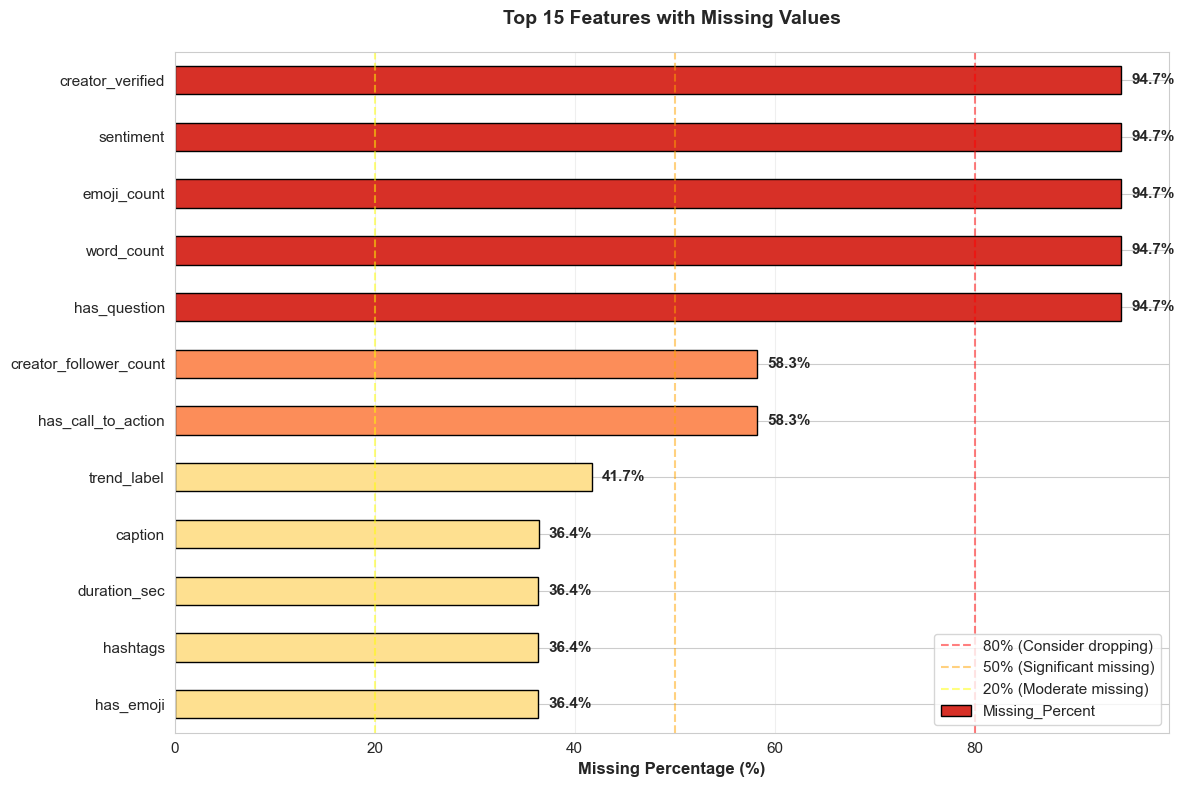

In [50]:
# Visualize missing data
fig, ax = plt.subplots(figsize=(12, 8))

# Plot top 15 features with missing values
top_missing = missing_summary.head(15)
colors = ['#d73027' if x > 80 else '#fc8d59' if x > 50 else '#fee090' if x > 20 else '#91bfdb' 
          for x in top_missing['Missing_Percent']]

top_missing['Missing_Percent'].plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_xlabel('Missing Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Features with Missing Values', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()

# Add percentage labels
for i, v in enumerate(top_missing['Missing_Percent']):
    ax.text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')

# Add threshold lines
ax.axvline(80, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='80% (Consider dropping)')
ax.axvline(50, color='orange', linestyle='--', alpha=0.5, linewidth=1.5, label='50% (Significant missing)')
ax.axvline(20, color='yellow', linestyle='--', alpha=0.5, linewidth=1.5, label='20% (Moderate missing)')

ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
# check critical features

# Check to see if any key features are missing 
print("\nKEY FEATURES:")
key_features = ['views', 'likes', 'comments', 'shares', 'saves', 'caption_length', 'hashtag_count']
for feature in key_features:
    if feature in df.columns:
        missing = df[feature].isnull().sum()
        pct = (missing / len(df) * 100)
        print(f"{feature}: {missing} missing ({pct:.2f}%)")




KEY FEATURES:
views: 0 missing (0.00%)
likes: 0 missing (0.00%)
comments: 0 missing (0.00%)
shares: 0 missing (0.00%)
saves: 0 missing (0.00%)
caption_length: 0 missing (0.00%)
hashtag_count: 0 missing (0.00%)


### Step 1.3: Duplicate Detection

Check for duplicate content IDs and potential bot/spam patterns

In [52]:
# Check for duplicate content IDs

n_duplicate_ids = df.duplicated(subset=['content_id']).sum()
pct_duplicate = (n_duplicate_ids / len(df)) * 100

print(f"\nDuplicate content_ids: {n_duplicate_ids} ({pct_duplicate:.2f}%)")

if n_duplicate_ids > 0:
    print("\n Warning: Found duplicate content IDs!")
    # Show a sample
    duplicate_ids = df[df.duplicated(subset=['content_id'], keep=False)].sort_values('content_id')
    print(f"\nSample of duplicate records (first 5):")
    print(duplicate_ids[['content_id', 'platform', 'category', 'views', 'engagement_score']].head())
else:
    print("No duplicate content IDs found")



Duplicate content_ids: 0 (0.00%)
No duplicate content IDs found


In [53]:
# Check for exact duplicate rows (all columns identical)
exact_duplicates = df.duplicated().sum()
pct_exact = (exact_duplicates / len(df)) * 100

print(f"Exact duplicate rows (all columns): {exact_duplicates} ({pct_exact:.2f}%)")

if exact_duplicates > 0:
    print("Found exact duplicate rows ")
else:
    print("No exact duplicate rows")

Exact duplicate rows (all columns): 0 (0.00%)
No exact duplicate rows


### Step 1.5: Sample Size Check for Subgroups

Check if we have sufficient samples for platform, category, and interaction analyses

In [54]:

platform_sizes = df['platform'].value_counts().sort_values(ascending=False)
print(f"\nTotal platforms: {len(platform_sizes)}\n")

for platform, count in platform_sizes.items():
    percentage = (count / len(df)) * 100
    print(f"{platform:15s}: {count:6,} ({percentage:5.2f}%)")

print(f"\nAll platforms have n > 1,000" if platform_sizes.min() > 1000 else "\n⚠️ Some platforms have small samples")



Total platforms: 3

tiktok         : 33,242 (40.31%)
instagram      : 29,999 (36.37%)
youtube        : 19,235 (23.32%)

All platforms have n > 1,000


In [55]:
# Check category distribution

category_sizes = df['category'].value_counts().head(20)
print(f"\nTotal unique categories: {df['category'].nunique()}\n")

for idx, (category, count) in enumerate(category_sizes.items(), 1):
    percentage = (count / len(df)) * 100
    print(f"{idx:2d}. {category:20s}: {count:6,} ({percentage:5.2f}%)")

# Check for very small categories
small_categories = (df['category'].value_counts() < 30).sum()
print(f"\nCategories with <30 samples: {small_categories}")




Total unique categories: 22

 1. Fitness             :  5,608 ( 6.80%)
 2. Food                :  5,567 ( 6.75%)
 3. Music               :  5,560 ( 6.74%)
 4. Lifestyle           :  5,555 ( 6.74%)
 5. Fashion             :  5,552 ( 6.73%)
 6. Beauty              :  5,494 ( 6.66%)
 7. Travel              :  5,467 ( 6.63%)
 8. Comedy              :  5,434 ( 6.59%)
 9. general             :  4,398 ( 5.33%)
10. Photography         :  3,035 ( 3.68%)
11. Technology          :  3,025 ( 3.67%)
12. Pets                :  2,626 ( 3.18%)
13. Tech                :  2,576 ( 3.12%)
14. Science             :  2,561 ( 3.11%)
15. Art                 :  2,548 ( 3.09%)
16. News                :  2,527 ( 3.06%)
17. DIY                 :  2,515 ( 3.05%)
18. Automotive          :  2,512 ( 3.05%)
19. Gaming              :  2,491 ( 3.02%)
20. Education           :  2,490 ( 3.02%)

Categories with <30 samples: 0


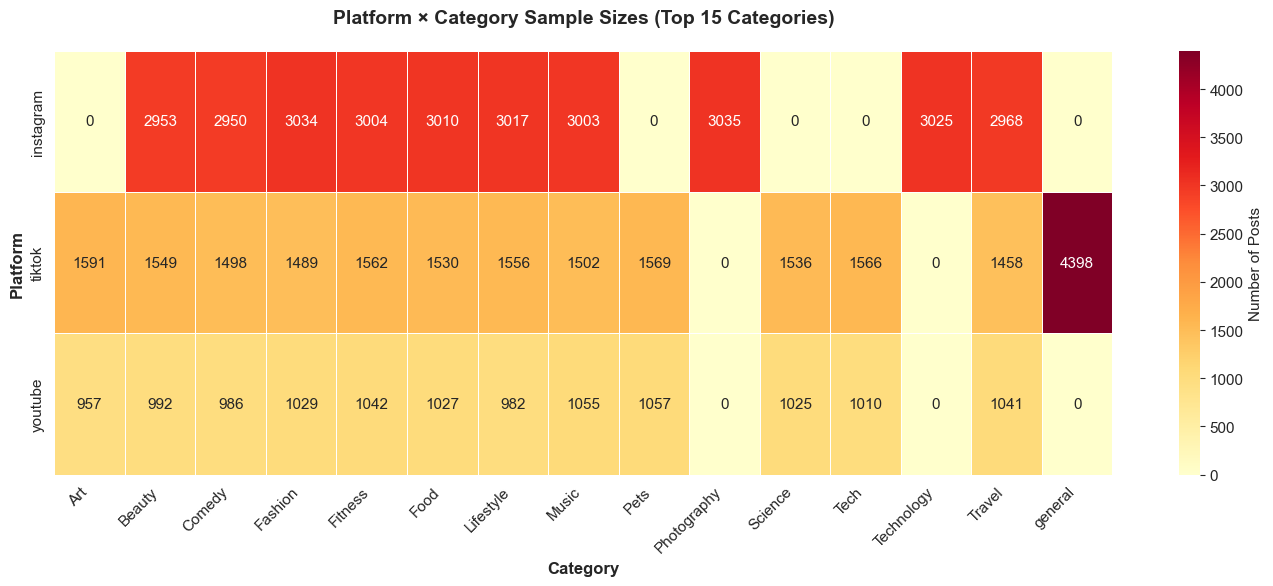

In [56]:
# Visualize platform × category heatmap
fig, ax = plt.subplots(figsize=(14, 6))

# Get top 15 categories for readability
top_categories = df['category'].value_counts().head(15).index
filtered_crosstab = pd.crosstab(df[df['category'].isin(top_categories)]['platform'], 
                                 df[df['category'].isin(top_categories)]['category'])

sns.heatmap(filtered_crosstab, annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={'label': 'Number of Posts'}, ax=ax, linewidths=0.5)
ax.set_title('Platform × Category Sample Sizes (Top 15 Categories)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Platform', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
